# Monocle Pancreas — λ_vf Sweep Plotting

Data extracted from run `monocle_pancreas_vf_sweep_20260524_174812`.  
Seeds 6–10 all complete.  
λ_lap fixed at 100.  
Epochs logged every 10 steps; epoch 140 is used as proxy for epoch 150 (final).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# λ_vf values — np.logspace(0, 4, 9)
LAMBDA_VFS = np.logspace(0, 4, 9)
print('lambda_vf values:', np.round(LAMBDA_VFS, 4))

lambda_vf values: [1.0000000e+00 3.1623000e+00 1.0000000e+01 3.1622800e+01 1.0000000e+02
 3.1622780e+02 1.0000000e+03 3.1622777e+03 1.0000000e+04]


In [2]:
# ---------------------------------------------------------------------------
# Raw data: r values logged every 10 epochs (i=0,10,...,140)
# Shape: [seed, lambda_idx, epoch_idx]  where epoch_idx ∈ {0,1,...,14} → epochs 0,10,...,140
# NaN = run not reached / log cut off
# Run: monocle_pancreas_vf_sweep_20260524_174812  |  Seeds 6–10  |  λ_lap=100
# ---------------------------------------------------------------------------

EPOCHS_LOGGED = list(range(0, 141, 10))  # 0, 10, ..., 140

# Each row = one lambda_vf, each column = one logged epoch (0,10,...,140)
seed6 = np.array([
    # lv=1e0
    [0.881, 0.932, 0.943, 0.945, 0.942, 0.941, 0.937, 0.903, 0.833, 0.591, 0.579, 0.571, 0.567, 0.564, 0.563],
    # lv=3.162e0
    [0.822, 0.948, 0.941, 0.852, 0.936, -0.207, -0.633, -0.772, -0.314, -0.658, -0.801, -0.648, -0.652, -0.643, -0.621],
    # lv=1e1
    [0.455, 0.945, 0.908, 0.892, 0.854, 0.939, 0.873, 0.915, 0.784, 0.912, 0.857, 0.897, 0.920, 0.919, 0.923],
    # lv=3.162e1
    [0.923, 0.935, 0.930, 0.913, 0.923, 0.923, 0.918, 0.926, 0.929, 0.928, 0.930, 0.926, 0.929, 0.925, 0.928],
    # lv=1e2
    [0.910, 0.459, 0.631, 0.837, 0.662, 0.386, 0.636, 0.764, 0.823, 0.807, 0.774, 0.791, 0.816, 0.821, 0.821],
    # lv=3.162e2
    [0.869, 0.488, 0.506, 0.683, 0.400, 0.008, -0.071, -0.021, -0.023, 0.042, 0.018, 0.164, 0.144, 0.952, 0.948],
    # lv=1e3
    [0.857, 0.953, 0.950, 0.942, 0.949, 0.949, 0.949, 0.948, 0.944, 0.909, 0.942, 0.504, 0.525, 0.594, 0.693],
    # lv=3.162e3
    [0.904, 0.944, 0.944, 0.943, 0.943, 0.945, 0.945, 0.943, 0.943, 0.938, 0.936, 0.906, 0.955, 0.941, 0.780],
    # lv=1e4
    [0.448, 0.875, 0.901, 0.615, 0.885, 0.862, 0.487, 0.885, 0.886, 0.850, 0.854, 0.797, 0.829, 0.844, 0.810],
])

seed7 = np.array([
    # lv=1e0
    [0.895, 0.895, 0.905, 0.900, 0.896, 0.894, 0.891, 0.890, 0.888, 0.887, 0.886, 0.887, 0.888, 0.889, 0.891],
    # lv=3.162e0
    [0.890, 0.906, 0.906, 0.906, 0.901, 0.899, 0.904, 0.905, 0.905, 0.906, 0.907, 0.907, 0.908, 0.909, 0.910],
    # lv=1e1
    [0.920, 0.941, 0.943, 0.919, 0.430, 0.946, 0.566, 0.412, 0.411, 0.419, 0.414, 0.417, 0.416, 0.416, 0.417],
    # lv=3.162e1
    [0.885, 0.942, 0.941, 0.939, 0.941, 0.579, 0.583, 0.587, 0.608, 0.612, 0.644, 0.646, 0.602, 0.573, 0.553],
    # lv=1e2
    [0.896, 0.890, 0.885, 0.896, 0.902, 0.902, 0.900, 0.899, 0.898, 0.898, 0.898, 0.897, 0.896, 0.896, 0.894],
    # lv=3.162e2
    [0.899, -0.259, -0.452, -0.169, 0.139, 0.057, -0.190, -0.296, -0.327, -0.342, -0.346, -0.353, -0.348, -0.333, -0.325],
    # lv=1e3
    [0.520, 0.927, 0.911, 0.910, 0.912, 0.908, 0.908, 0.903, 0.885, 0.899, 0.723, 0.643, 0.610, 0.868, 0.907],
    # lv=3.162e3
    [0.903, 0.925, 0.933, 0.925, 0.929, 0.938, 0.935, 0.928, 0.940, 0.941, 0.923, 0.895, 0.886, 0.900, 0.878],
    # lv=1e4
    [0.907, 0.927, 0.921, 0.923, 0.927, 0.923, 0.898, 0.884, 0.878, 0.926, 0.888, 0.924, 0.870, 0.819, 0.802],
])

seed8 = np.array([
    # lv=1e0
    [0.777, 0.949, 0.932, 0.936, 0.940, 0.941, 0.941, 0.941, 0.941, 0.940, 0.939, 0.930, 0.939, 0.933, 0.913],
    # lv=3.162e0
    [0.892, 0.923, 0.349, 0.432, 0.460, 0.482, 0.502, 0.524, 0.584, 0.636, 0.724, 0.761, 0.778, 0.781, 0.787],
    # lv=1e1
    [0.909, 0.485, 0.509, 0.506, 0.493, 0.384, 0.159, 0.103, 0.075, 0.057, 0.052, 0.049, 0.050, 0.052, 0.049],
    # lv=3.162e1
    [0.879, 0.914, 0.905, 0.908, 0.908, 0.911, 0.912, 0.915, 0.918, 0.921, 0.925, 0.925, 0.924, 0.921, 0.927],
    # lv=1e2
    [0.907, 0.880, 0.857, 0.850, 0.848, 0.829, 0.791, 0.785, 0.850, 0.884, 0.878, 0.874, 0.871, 0.866, 0.863],
    # lv=3.162e2
    [0.903, 0.893, 0.784, 0.843, 0.840, -0.509, 0.552, 0.017, -0.795, -0.819, -0.526, -0.814, 0.818, -0.819, 0.819],
    # lv=1e3
    [0.460, 0.911, -0.405, 0.900, 0.922, 0.469, 0.163, 0.229, 0.161, 0.104, 0.044, 0.008, -0.030, -0.101, -0.256],
    # lv=3.162e3
    [0.926, 0.925, 0.935, 0.942, 0.943, 0.942, 0.942, 0.941, 0.941, 0.941, 0.941, 0.940, 0.941, 0.942, 0.942],
    # lv=1e4
    [0.919, 0.926, 0.926, 0.940, 0.932, 0.530, 0.821, 0.397, 0.439, 0.469, 0.453, 0.456, 0.438, 0.423, 0.419],
])

seed9 = np.array([
    # lv=1e0
    [0.513, 0.933, 0.936, 0.930, 0.935, 0.929, 0.931, 0.928, 0.927, 0.928, 0.927, 0.926, 0.926, 0.926, 0.926],
    # lv=3.162e0
    [0.881, 0.951, 0.938, 0.934, 0.935, 0.933, 0.928, 0.926, 0.926, 0.922, 0.919, 0.919, 0.918, 0.916, 0.917],
    # lv=1e1
    [0.910, 0.948, 0.948, 0.944, 0.939, 0.934, 0.942, 0.927, 0.937, 0.933, 0.920, 0.903, 0.902, 0.898, 0.873],
    # lv=3.162e1
    [0.931, 0.945, 0.940, 0.945, 0.943, 0.943, 0.942, 0.943, 0.943, 0.944, 0.943, 0.940, 0.936, 0.929, 0.927],
    # lv=1e2
    [0.853, 0.947, 0.945, 0.947, 0.944, 0.944, 0.943, 0.944, 0.943, 0.943, 0.942, 0.943, 0.942, 0.941, 0.940],
    # lv=3.162e2
    [0.819, 0.930, 0.936, 0.939, 0.937, 0.936, 0.936, 0.936, 0.936, 0.936, 0.936, 0.937, 0.936, 0.937, 0.938],
    # lv=1e3
    [0.884, 0.945, 0.945, 0.944, 0.944, 0.922, 0.940, 0.908, 0.925, 0.925, 0.832, 0.606, 0.870, 0.841, 0.847],
    # lv=3.162e3
    [0.880, 0.909, 0.908, 0.906, 0.897, 0.880, 0.835, 0.532, 0.487, 0.531, 0.425, 0.400, 0.369, 0.391, 0.408],
    # lv=1e4
    [0.893, 0.940, 0.941, 0.945, 0.943, 0.946, 0.936, 0.909, 0.872, 0.894, 0.863, 0.768, 0.830, 0.863, 0.843],
])

seed10 = np.array([
    # lv=1e0
    [0.902, 0.928, 0.918, 0.913, 0.922, 0.921, 0.922, 0.923, 0.922, 0.922, 0.922, 0.921, 0.921, 0.921, 0.922],
    # lv=3.162e0
    [0.927, 0.945, 0.922, 0.937, 0.504, 0.529, 0.593, 0.828, 0.838, 0.834, 0.832, 0.830, 0.829, 0.828, 0.828],
    # lv=1e1
    [0.802, 0.946, 0.927, 0.939, 0.924, 0.834, 0.837, 0.860, 0.852, -0.891, -0.496, 0.305, -0.901, -0.900, 0.366],
    # lv=3.162e1
    [0.884, 0.944, 0.924, 0.922, 0.678, 0.623, 0.636, 0.568, 0.574, 0.592, 0.598, 0.598, 0.600, 0.603, 0.607],
    # lv=1e2
    [0.911, 0.942, 0.846, 0.896, 0.933, 0.880, 0.921, 0.923, 0.931, 0.927, 0.909, 0.924, 0.928, 0.924, 0.921],
    # lv=3.162e2
    [0.884, 0.933, 0.929, 0.922, 0.923, 0.927, 0.917, 0.928, 0.917, 0.930, 0.924, 0.924, 0.924, 0.872, 0.880],
    # lv=1e3
    [0.913, 0.944, 0.941, 0.937, 0.936, 0.933, 0.936, 0.935, 0.930, 0.931, 0.929, 0.931, 0.930, 0.933, 0.936],
    # lv=3.162e3
    [0.905, 0.928, 0.937, 0.950, 0.933, 0.950, 0.943, 0.944, 0.942, 0.936, 0.942, 0.945, 0.939, 0.936, 0.919],
    # lv=1e4
    [0.910, 0.459, 0.427, 0.453, 0.457, 0.471, 0.509, 0.532, 0.489, 0.810, 0.220, 0.308, 0.315, 0.166, 0.080],
])

# Stack: shape (5, 9, 15)  — seeds × lambdas × logged_epochs
all_seeds = np.stack([seed6, seed7, seed8, seed9, seed10], axis=0)
print('all_seeds shape:', all_seeds.shape)  # (5, 9, 15)

all_seeds shape: (5, 9, 15)


In [3]:
# ---------------------------------------------------------------------------
# Summary: r at epoch ~50 (idx 5), ~100 (idx 10), ~140 (idx 14)
# ---------------------------------------------------------------------------

EPOCH_IDX = {'~50': 5, '~100': 10, '~140': 14}

# Mean and std ignoring NaN
summary = {}
for label, eidx in EPOCH_IDX.items():
    vals = all_seeds[:, :, eidx]  # (5, 9)
    summary[label] = {
        'mean': np.nanmean(vals, axis=0),
        'std':  np.nanstd(vals, axis=0),
        'per_seed': vals,
    }

df_summary = pd.DataFrame({
    'lambda_vf': LAMBDA_VFS,
    'ep50_mean':  summary['~50']['mean'],
    'ep50_std':   summary['~50']['std'],
    'ep100_mean': summary['~100']['mean'],
    'ep100_std':  summary['~100']['std'],
    'ep140_mean': summary['~140']['mean'],
    'ep140_std':  summary['~140']['std'],
})
df_summary

,lambda_vf,ep50_mean,ep50_std,ep100_mean,ep100_std,ep140_mean,ep140_std
0,1.000000,0.9252,0.017348,0.8506,0.136945,0.8430,0.140523
1,3.162278,0.5272,0.410854,0.5162,0.662254,0.5642,0.594639
2,10.000000,0.8074,0.215653,0.3494,0.527364,0.5256,0.329553
3,31.622777,0.7958,0.159988,0.8080,0.153489,0.7884,0.171013
4,100.000000,0.7882,0.204490,0.8802,0.057007,0.8878,0.042291
5,316.227766,0.2838,0.564820,0.2012,0.620352,0.6520,0.490676
6,1000.000000,0.8362,0.184091,0.6940,0.334399,0.6254,0.448623
7,3162.277660,0.9310,0.025799,0.8334,0.204312,0.7854,0.196676
8,10000.000000,0.7464,0.203502,0.6556,0.270991,0.5908,0.298895


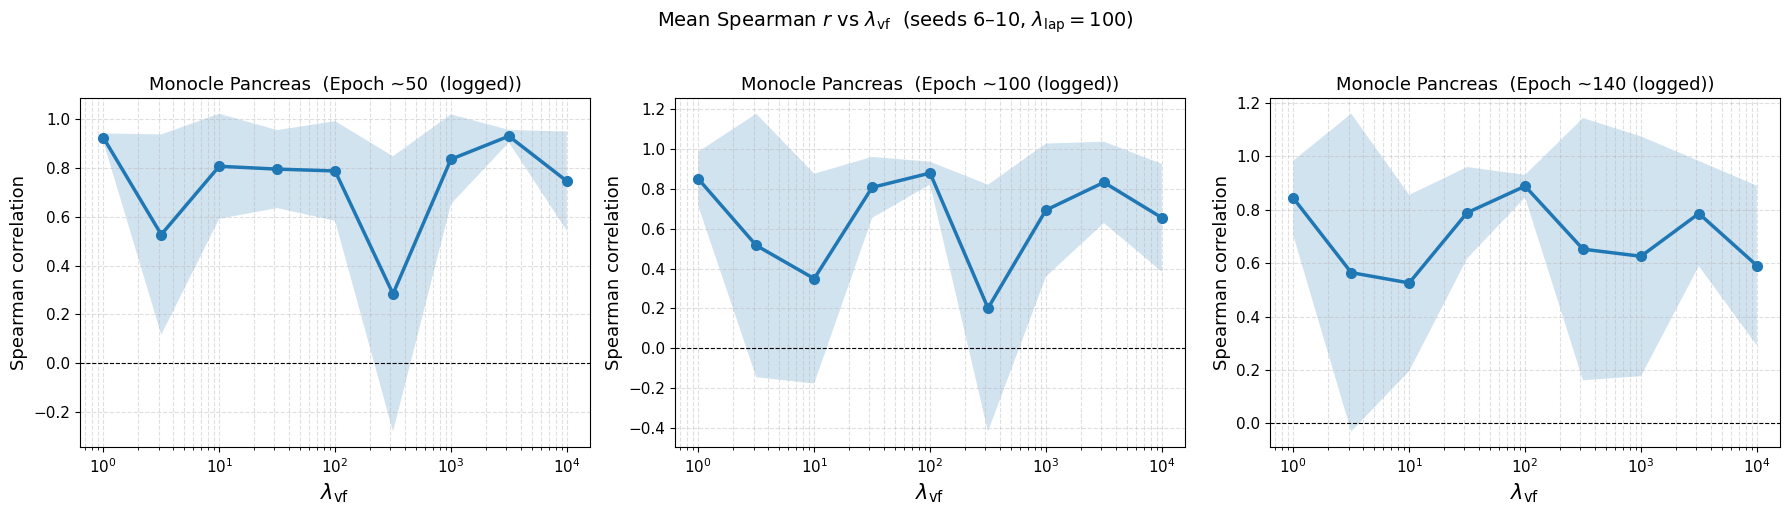

In [4]:
# ---------------------------------------------------------------------------
# Plot 1: Mean ± std across seeds — one panel per epoch checkpoint
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

checkpoints = [
    ('~50',  'Epoch ~50  (logged)',  axes[0]),
    ('~100', 'Epoch ~100 (logged)',  axes[1]),
    ('~140', 'Epoch ~140 (logged)',  axes[2]),
]

for label, title, ax in checkpoints:
    mu  = summary[label]['mean']
    sig = summary[label]['std']
    ax.semilogx(LAMBDA_VFS, mu, marker='o', linewidth=2.5, markersize=7)
    ax.fill_between(LAMBDA_VFS, mu - sig, mu + sig, alpha=0.2)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=15)
    ax.set_ylabel('Spearman correlation', fontsize=13)
    ax.set_title(f'Monocle Pancreas  ({title})', fontsize=13)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=11)

plt.suptitle(r'Mean Spearman $r$ vs $\lambda_{\mathrm{vf}}$  (seeds 6–10, $\lambda_{\mathrm{lap}}=100$)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('vf_sweep_mean_std.png', dpi=200, bbox_inches='tight')
plt.show()

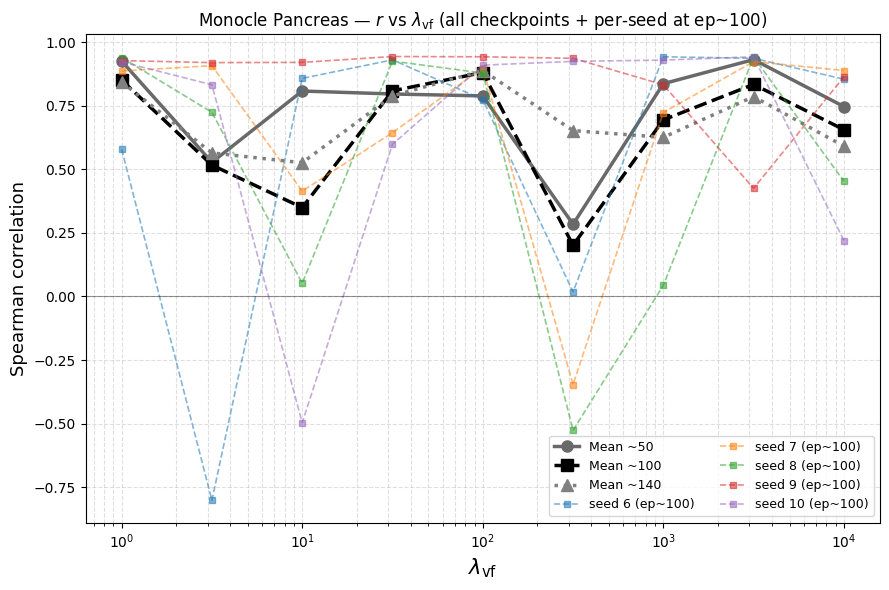

In [5]:
# ---------------------------------------------------------------------------
# Plot 2: Per-seed traces + mean — all three checkpoints overlaid on one plot
# ---------------------------------------------------------------------------

seed_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
seed_labels_all = ['seed 6', 'seed 7', 'seed 8', 'seed 9', 'seed 10']
checkpoint_styles = {'~50': ('o', '-'), '~100': ('s', '--'), '~140': ('^', ':')}

fig, ax = plt.subplots(figsize=(9, 6))

for label, (marker, ls) in checkpoint_styles.items():
    mu = summary[label]['mean']
    ax.semilogx(LAMBDA_VFS, mu, marker=marker, linestyle=ls,
                linewidth=2.5, markersize=8, label=f'Mean {label}',
                color='black' if label == '~100' else ('dimgray' if label == '~50' else 'gray'))

# Individual seeds at epoch ~100
for s_idx, (color, seed_label) in enumerate(zip(seed_colors, seed_labels_all)):
    vals = all_seeds[s_idx, :, EPOCH_IDX['~100']]
    ax.semilogx(LAMBDA_VFS, vals, marker='s', linestyle='--',
                linewidth=1.2, markersize=5, alpha=0.55, color=color, label=f'{seed_label} (ep~100)')

ax.axhline(0, color='k', linewidth=0.8, linestyle='-', alpha=0.4)
ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=15)
ax.set_ylabel('Spearman correlation', fontsize=13)
ax.set_title(r'Monocle Pancreas — $r$ vs $\lambda_{\mathrm{vf}}$ (all checkpoints + per-seed at ep~100)', fontsize=12)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('vf_sweep_overlay.png', dpi=200, bbox_inches='tight')
plt.show()

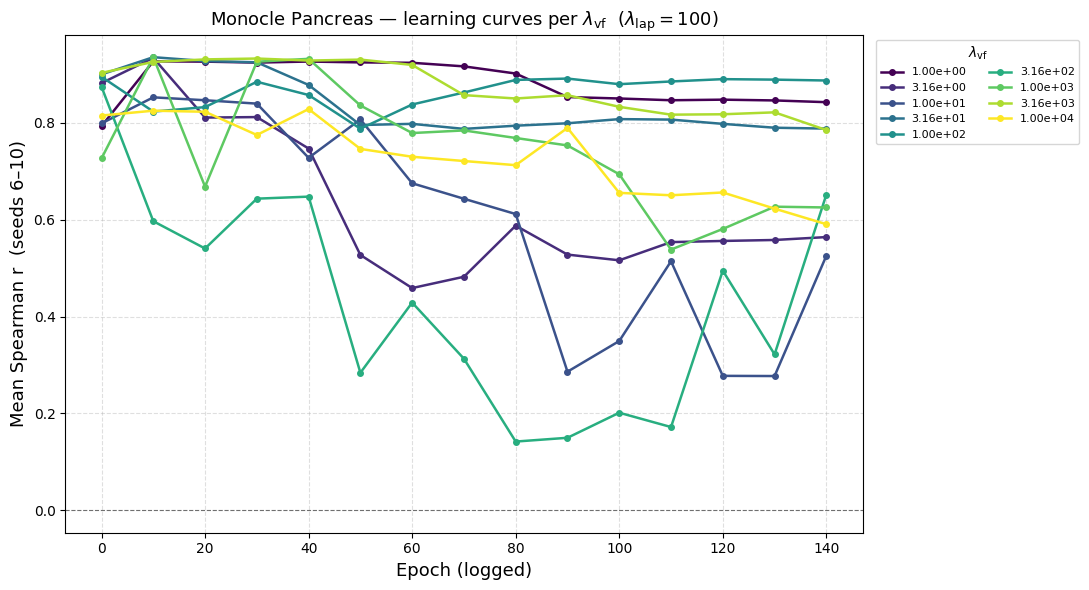

In [6]:
# ---------------------------------------------------------------------------
# Plot 3: Learning curves (r vs epoch) for each λ_vf — mean across seeds
# ---------------------------------------------------------------------------

epochs_arr = np.array(EPOCHS_LOGGED)

# Mean across seeds (nanmean)
mean_curves = np.nanmean(all_seeds, axis=0)  # (9, 15)

cmap = plt.cm.viridis
colors = [cmap(i / 8) for i in range(9)]

fig, ax = plt.subplots(figsize=(11, 6))
for lv_idx in range(9):
    lv_val = LAMBDA_VFS[lv_idx]
    curve = mean_curves[lv_idx]
    ax.plot(epochs_arr, curve, marker='o', markersize=4, linewidth=1.8,
            color=colors[lv_idx], label=f'{lv_val:.2e}')

ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch (logged)', fontsize=13)
ax.set_ylabel('Mean Spearman r  (seeds 6–10)', fontsize=13)
ax.set_title(r'Monocle Pancreas — learning curves per $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=100$)', fontsize=13)
ax.legend(title=r'$\lambda_{\mathrm{vf}}$', fontsize=8, ncol=2,
          bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('vf_sweep_learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()

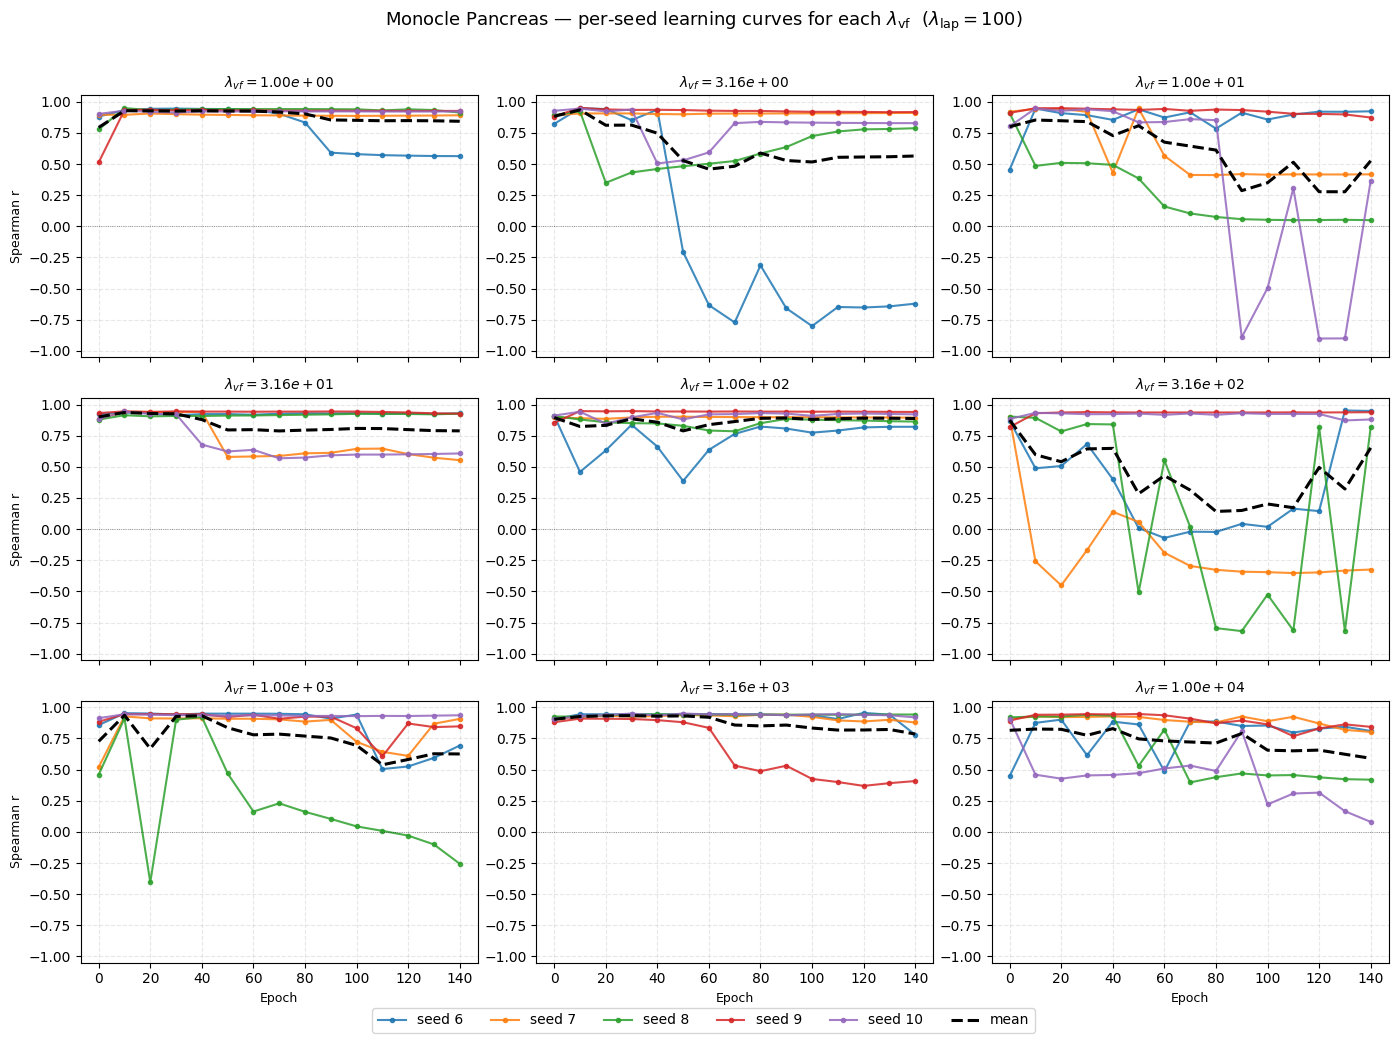

In [7]:
# ---------------------------------------------------------------------------
# Plot 4: Per-seed learning curves (small multiples) for each λ_vf
# ---------------------------------------------------------------------------

n_lv = 9
ncols = 3
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 10), sharex=True)

seed_labels = ['seed 6', 'seed 7', 'seed 8', 'seed 9', 'seed 10']
seed_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

for lv_idx, ax in enumerate(axes.flat):
    lv_val = LAMBDA_VFS[lv_idx]
    for s_idx in range(5):
        curve = all_seeds[s_idx, lv_idx, :]
        ax.plot(epochs_arr, curve, marker='o', markersize=3, linewidth=1.5,
                color=seed_colors[s_idx], label=seed_labels[s_idx], alpha=0.85)
    # mean
    ax.plot(epochs_arr, np.nanmean(all_seeds[:, lv_idx, :], axis=0),
            color='black', linewidth=2.2, linestyle='--', label='mean')
    ax.axhline(0, color='k', linewidth=0.6, linestyle=':', alpha=0.5)
    ax.set_title(rf'$\lambda_{{vf}}={lv_val:.2e}$', fontsize=10)
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, linestyle='--', alpha=0.3)
    if lv_idx % ncols == 0:
        ax.set_ylabel('Spearman r', fontsize=9)
    if lv_idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Epoch', fontsize=9)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(r'Monocle Pancreas — per-seed learning curves for each $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=100$)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('vf_sweep_per_seed_grid.png', dpi=200, bbox_inches='tight')
plt.show()

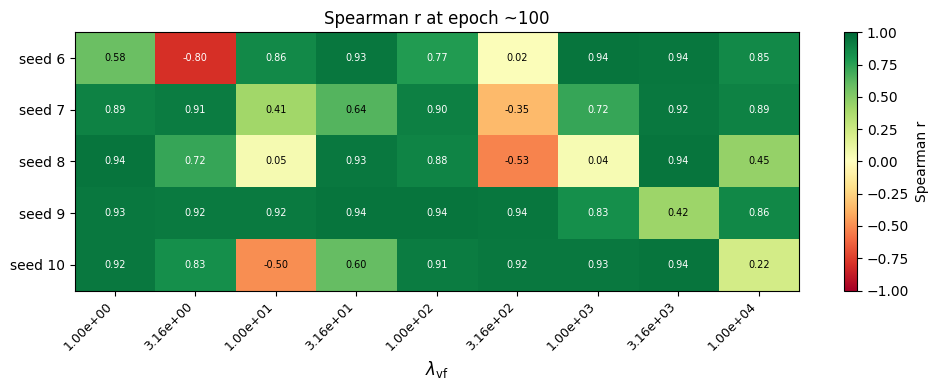

In [8]:
# ---------------------------------------------------------------------------
# Heatmap: r at epoch ~100 for all seeds × all lambda_vfs
# ---------------------------------------------------------------------------

r_ep100 = all_seeds[:, :, EPOCH_IDX['~100']]  # (5, 9)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(r_ep100, aspect='auto', cmap='RdYlGn', vmin=-1.0, vmax=1.0)
ax.set_xticks(range(9))
ax.set_xticklabels([f'{v:.2e}' for v in LAMBDA_VFS], rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(5))
ax.set_yticklabels(['seed 6', 'seed 7', 'seed 8', 'seed 9', 'seed 10'])
ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=12)
ax.set_title('Spearman r at epoch ~100', fontsize=12)
plt.colorbar(im, ax=ax, label='Spearman r')

# Annotate values
for i in range(5):
    for j in range(9):
        val = r_ep100[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if abs(val) < 0.7 else 'white')

plt.tight_layout()
plt.savefig('vf_sweep_heatmap_ep100.png', dpi=200, bbox_inches='tight')
plt.show()

In [9]:
# ---------------------------------------------------------------------------
# Summary table — best lambda_vf per epoch checkpoint
# ---------------------------------------------------------------------------

print('Best lambda_vf by mean r:\n')
for label in ['~50', '~100', '~140']:
    mu = summary[label]['mean']
    best_idx = np.nanargmax(mu)
    print(f'  Epoch {label:5s}:  lambda_vf = {LAMBDA_VFS[best_idx]:.3e}  '
          f'→  mean r = {mu[best_idx]:.3f}  (std={summary[label]["std"][best_idx]:.3f})')

print()
print(df_summary.to_string(index=False, float_format='{:.3f}'.format))

Best lambda_vf by mean r:

  Epoch ~50  :  lambda_vf = 3.162e+03  →  mean r = 0.931  (std=0.026)
  Epoch ~100 :  lambda_vf = 1.000e+02  →  mean r = 0.880  (std=0.057)
  Epoch ~140 :  lambda_vf = 1.000e+02  →  mean r = 0.888  (std=0.042)

 lambda_vf  ep50_mean  ep50_std  ep100_mean  ep100_std  ep140_mean  ep140_std
     1.000      0.925     0.017       0.851      0.137       0.843      0.141
     3.162      0.527     0.411       0.516      0.662       0.564      0.595
    10.000      0.807     0.216       0.349      0.527       0.526      0.330
    31.623      0.796     0.160       0.808      0.153       0.788      0.171
   100.000      0.788     0.204       0.880      0.057       0.888      0.042
   316.228      0.284     0.565       0.201      0.620       0.652      0.491
  1000.000      0.836     0.184       0.694      0.334       0.625      0.449
  3162.278      0.931     0.026       0.833      0.204       0.785      0.197
 10000.000      0.746     0.204       0.656      0.271      